Problem statement:
Using the historical students data given to you, build an Multi linear regression model that predicts a new students performance index based on various factors like

hours studied
Previous score
Extracurr activities
Sleeping hours
Sample question papers practiced

In [3]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/content/sample_data/Student_Performance.csv.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


In [10]:
df.shape

(10000, 6)

In [11]:
## Check null and duplicates
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [13]:
df.duplicated().sum()

np.int64(127)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.shape

(9873, 6)

In [24]:
## mapping extra curr to Yes: 1, No: 0

df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

df

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     9873 non-null   int64
 1   Previous Scores                   9873 non-null   int64
 2   Extracurricular Activities        9873 non-null   int64
 3   Sleep Hours                       9873 non-null   int64
 4   Sample Question Papers Practiced  9873 non-null   int64
 5   Performance Index                 9873 non-null   int64
dtypes: int64(6)
memory usage: 539.9 KB


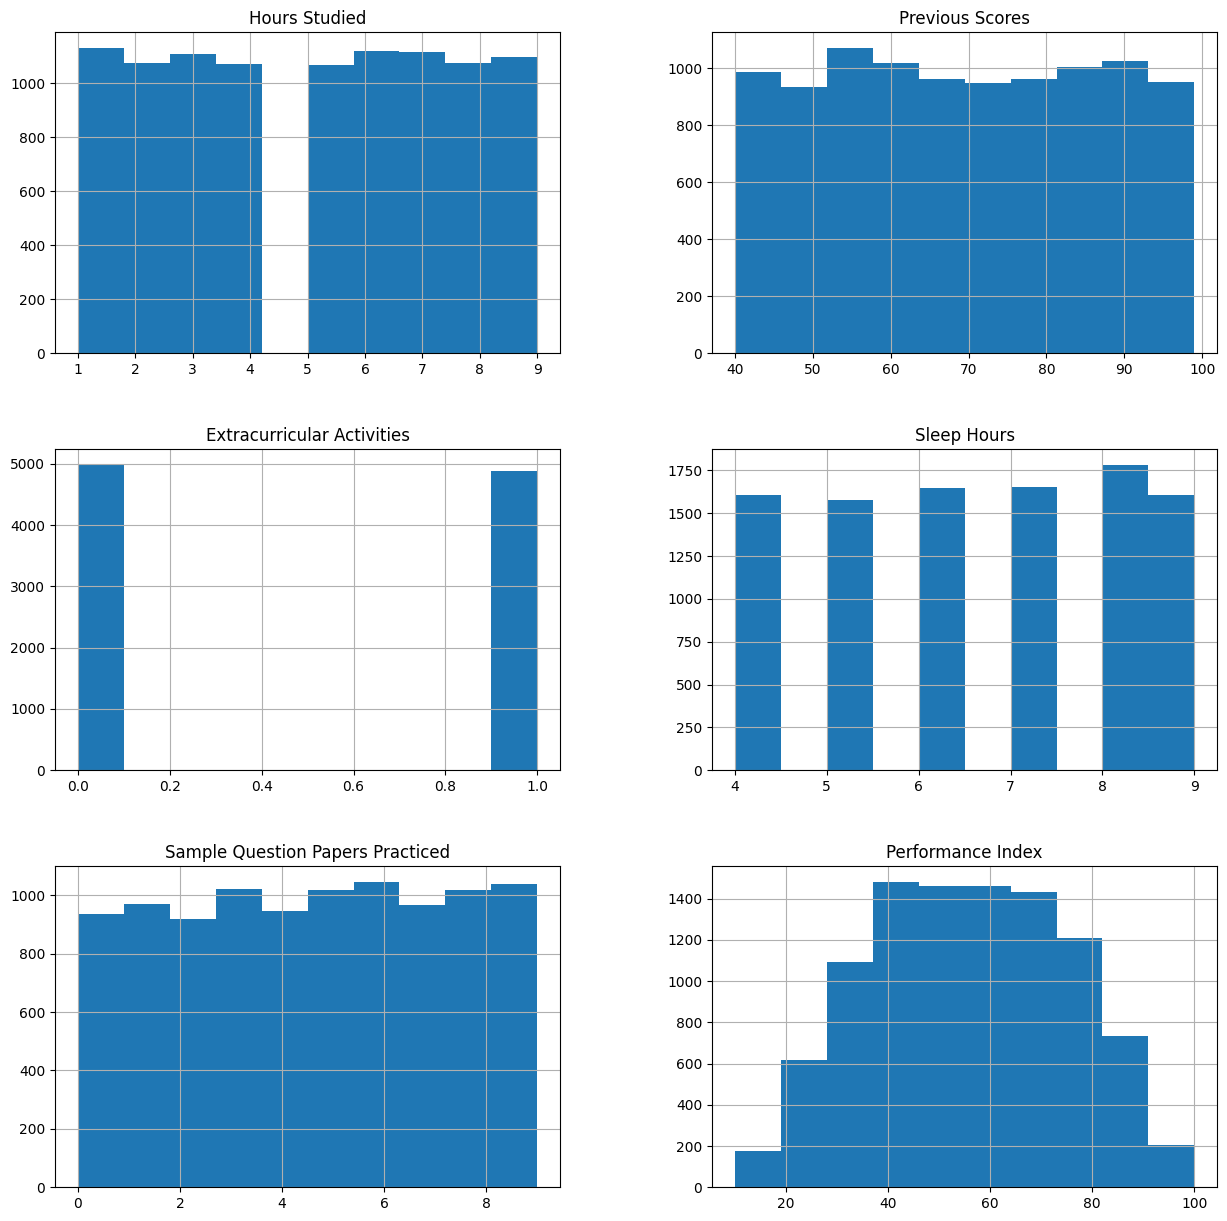

In [28]:
## Univariate analysis
df.hist(figsize=(15,15));

<Axes: >

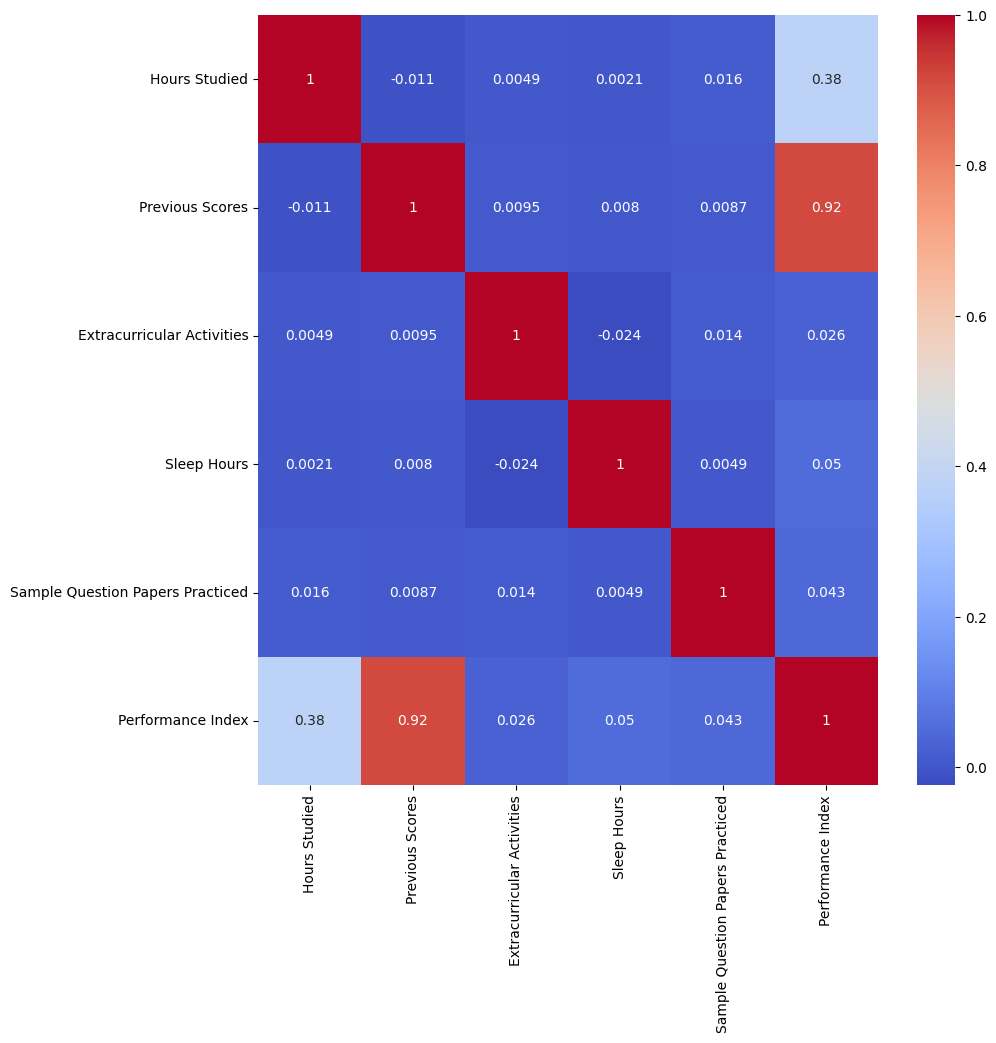

In [29]:
## Correlation using heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
#

In [33]:
## Outlier detection

for col in df:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  LB = Q1 - 1.5*IQR
  UB = Q3 + 1.5*IQR

  outliers = df[(df[col] < LB) | (df[col] > UB)]
  print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in Hours Studied: 0
Number of outliers in Previous Scores: 0
Number of outliers in Extracurricular Activities: 0
Number of outliers in Sleep Hours: 0
Number of outliers in Sample Question Papers Practiced: 0
Number of outliers in Performance Index: 0


ML model building

In [34]:
X = df.drop('Performance Index',axis=1)
y = df['Performance Index']

In [36]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [37]:
y

,Performance Index
0,91
1,65
2,45
3,36
4,66
...,...
9995,23
9996,58
9997,74
9998,95


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()

In [40]:
lr.fit(X_train, y_train)

LinearRegression()

In [41]:
coeff = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])

In [42]:
coeff

,Coefficient
Hours Studied,2.851022
Previous Scores,1.018430
Extracurricular Activities,0.573823
Sleep Hours,0.472073
Sample Question Papers Practiced,0.188704


In [43]:
## print intercept

print(lr.intercept_)

-33.981324496440635


In [44]:
## Prediction on X_test

y_pred = lr.predict(X_test)

In [45]:
## Model evalaution

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [46]:
## print

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 4.305900938538479
Mean Absolute Error: 1.6469703984255573
Root Mean Squared Error: 2.0750664901488047
R-squared: 0.9884301209927054
